<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


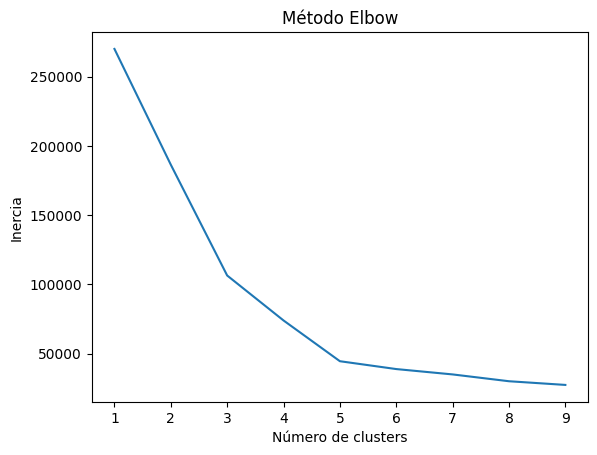

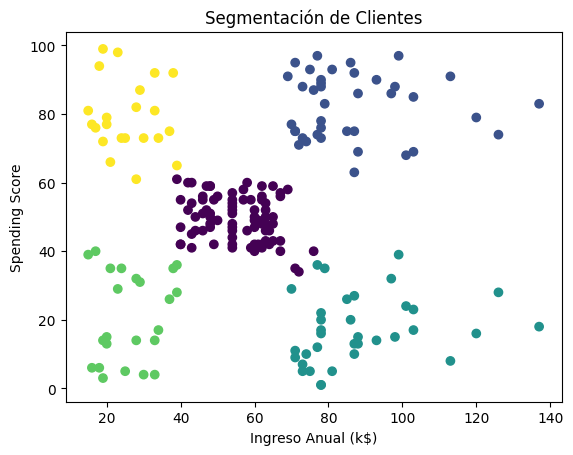

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

sys.path.append("..")

from src.clustering import crear_clusters
from sklearn.cluster import KMeans

df = pd.read_csv("../data/Mall_Customers.csv")

df.head()
df.info()
df.describe()
df.isnull().sum()

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

inertia = []

K = range(1,10)

for k in K:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia)
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método Elbow")

plt.show()

df["cluster"] = crear_clusters(X, n_clusters=5)

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["cluster"]
)

plt.xlabel("Ingreso Anual (k$)")
plt.ylabel("Spending Score")
plt.title("Segmentación de Clientes")

plt.show()